# Phase 1

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

# Root Project Directory
PROJECT_ROOT = "/content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense"

# Folder Structure
folders = [
    "data",
    "models/base_models",
    "models/defense_models",
    "explanations/shap",
    "explanations/lime",
    "explanations/ig",
    "attacks",
    "metrics",
    "figures",
    "logs"
]

# Create Folders
for folder in folders:
    full_path = os.path.join(PROJECT_ROOT, folder)
    os.makedirs(full_path, exist_ok=True)
    print("Created:", full_path)

print("\nProject folders created successfully!")

Created: /content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense/data
Created: /content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense/models/base_models
Created: /content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense/models/defense_models
Created: /content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense/explanations/shap
Created: /content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense/explanations/lime
Created: /content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense/explanations/ig
Created: /content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense/attacks
Created: /content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense/metrics
Created: /content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense/figures
Created: /content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense/logs

Pr

In [4]:
PROJECT_ROOT = "/content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense"

In [5]:
!pip install shap lime captum xgboost tqdm seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of captum to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.3 MB/s eta 0:00:00
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=8c09a5bca22c12a20481817923920a97255581d8d77d0d2c524489c2cb27ac19
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

import shap
from lime import lime_tabular
from captum.attr import IntegratedGradients

import xgboost as xgb
import pickle

from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore")

In [7]:
def save_model(model, path):
    torch.save(model.state_dict(), path)

def load_model(model, path):
    model.load_state_dict(torch.load(path))
    return model

def save_pickle(obj, path):
    with open(path, "wb") as f:
        pickle.dump(obj, f)

def load_pickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)

def save_numpy(arr, path):
    np.save(path, arr)

def load_numpy(path):
    return np.load(path)

In [8]:
def save_and_show_plot(name):
    path = os.path.join(PROJECT_ROOT, "figures", name)
    plt.savefig(path, bbox_inches='tight')
    plt.show()
    print(f"Saved: {path}")

In [9]:
print("Project Root:", PROJECT_ROOT)

print("\nFolders:")
for folder in folders:
    print("-", folder)

Project Root: /content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense

Folders:
- data
- models/base_models
- models/defense_models
- explanations/shap
- explanations/lime
- explanations/ig
- attacks
- metrics
- figures
- logs


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

import os
import pickle
import json

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

import warnings
warnings.filterwarnings("ignore")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [11]:
def save_pickle(obj, path):
    with open(path, "wb") as f:
        pickle.dump(obj, f)


def load_pickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)


def save_numpy(arr, path):
    np.save(path, arr)


def load_numpy(path):
    return np.load(path)


def save_torch_model(model, path):
    torch.save(model.state_dict(), path)


def load_torch_model(model, path):
    model.load_state_dict(torch.load(path))
    return model

print("Save / Load Utilities Ready")

Save / Load Utilities Ready


In [12]:
def save_and_show_plot(name):

    save_path = os.path.join(PROJECT_ROOT, "figures", name)

    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

    print(f"Saved Figure → {save_path}")

In [13]:
CONFIG = {
    "random_seed": 42,
    "test_size": 0.2,
    "batch_size": 64,
    "epochs": 30,
    "learning_rate": 0.001
}

config_path = os.path.join(PROJECT_ROOT, "logs", "config.json")

with open(config_path, "w") as f:
    json.dump(CONFIG, f)

print("Config saved at:", config_path)

Config saved at: /content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense/logs/config.json


In [14]:
print("Project Root:", PROJECT_ROOT)

print("\nChecking folders...")

for root, dirs, files in os.walk(PROJECT_ROOT):
    print(root)

Project Root: /content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense

Checking folders...
/content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense
/content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense/data
/content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense/models
/content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense/models/base_models
/content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense/models/defense_models
/content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense/explanations
/content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense/explanations/shap
/content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense/explanations/lime
/content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense/explanations/ig
/content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Atta

# Dataset Loading and Preprocessing

In [15]:
import random

def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

print("Random Seed Set")

Random Seed Set


In [16]:
import os

data_folder = os.path.join(PROJECT_ROOT, "data")

print("Files in DATA folder:\n")

for root, dirs, files in os.walk(data_folder):
    level = root.replace(data_folder, '').count(os.sep)
    indent = ' ' * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f"{subindent}{f}")

Files in DATA folder:

data/
    Fraudulent_online_shops_dataset.csv
    PhiUSIIL_Phishing_URL_Dataset.csv
    cybersecurity_intrusion_data.csv
    X_train_phish.npy
    X_test_phish.npy
    X_train_ids.npy
    X_test_ids.npy
    X_train_fraud.npy
    X_test_fraud.npy
    y_train_phish.npy
    y_test_phish.npy
    y_train_ids.npy
    y_test_ids.npy
    y_train_fraud.npy
    y_test_fraud.npy
    feature_phish.pkl
    feature_ids.pkl
    feature_fraud.pkl


In [17]:
# Dataset Paths

PHISHING_PATH = os.path.join(PROJECT_ROOT, "data", "PhiUSIIL_Phishing_URL_Dataset.csv")
IDS_PATH = os.path.join(PROJECT_ROOT, "data", "cybersecurity_intrusion_data.csv")
FRAUD_PATH = os.path.join(PROJECT_ROOT, "data", "Fraudulent_online_shops_dataset.csv")

print("Datasets Found:\n")
print("Phishing:", PHISHING_PATH)
print("IDS:", IDS_PATH)
print("Fraud:", FRAUD_PATH)

Datasets Found:

Phishing: /content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense/data/PhiUSIIL_Phishing_URL_Dataset.csv
IDS: /content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense/data/cybersecurity_intrusion_data.csv
Fraud: /content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense/data/Fraudulent_online_shops_dataset.csv


In [18]:
# Load datasets

phishing_df = pd.read_csv(PHISHING_PATH)
ids_df = pd.read_csv(IDS_PATH)
fraud_df = pd.read_csv(FRAUD_PATH)

print("Phishing Shape:", phishing_df.shape)
print("IDS Shape:", ids_df.shape)
print("Fraud Shape:", fraud_df.shape)

Phishing Shape: (235795, 56)
IDS Shape: (9537, 11)
Fraud Shape: (1140, 26)


In [19]:
print("\nPhishing Columns:\n", phishing_df.columns)

print("\nIDS Columns:\n", ids_df.columns)

print("\nFraud Columns:\n", fraud_df.columns)


Phishing Columns:
 Index(['FILENAME', 'URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP',
       'TLD', 'URLSimilarityIndex', 'CharContinuationRate',
       'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain',
       'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio',
       'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL',
       'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL',
       'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL',
       'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength',
       'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore',
       'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect',
       'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame',
       'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton',
       'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto',
       'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef',
       '

In [20]:
def preprocess_dataset(df, label_column, drop_columns=[]):

    print("\n-----------------------------")
    print("Starting Preprocessing")
    print("-----------------------------")

    # Drop unwanted columns
    df = df.drop(columns=drop_columns, errors='ignore')

    # Separate target
    y = df[label_column]
    X = df.drop(columns=[label_column])

    # Save feature names
    feature_names = X.columns.tolist()

    # Handle categorical features
    for col in X.columns:
        if X[col].dtype == 'object':
            X[col] = X[col].astype(str)
            X[col] = X[col].factorize()[0]

    # Fill missing values
    X = X.fillna(X.mean())

    # Scaling
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Train Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    print("Train Shape:", X_train.shape)
    print("Test Shape:", X_test.shape)

    return X_train, X_test, y_train, y_test, feature_names, scaler

We observed that URLSimilarityIndex in the phishing dataset exhibited constant behavior for phishing samples, potentially leading to inflated model reliance. Therefore, we excluded this feature to ensure realistic model behavior.

In [21]:
phishing_drop = [
    "FILENAME",
    "URL",
    "Domain",
    "Title",
    "URLSimilarityIndex"   # add this
]
ids_drop = [
    "session_id"
]
fraud_drop = [
    "Online shop URL",
    "Domain registration date"
]

In [22]:
# Phishing
X_train_phish, X_test_phish, y_train_phish, y_test_phish, feature_phish, scaler_phish = preprocess_dataset(
    phishing_df,
    "label",
    phishing_drop
)

# IDS
X_train_ids, X_test_ids, y_train_ids, y_test_ids, feature_ids, scaler_ids = preprocess_dataset(
    ids_df,
    "attack_detected",
    ids_drop
)

# Fraud
X_train_fraud, X_test_fraud, y_train_fraud, y_test_fraud, feature_fraud, scaler_fraud = preprocess_dataset(
    fraud_df,
    "Label",
    fraud_drop
)


-----------------------------
Starting Preprocessing
-----------------------------
Train Shape: (188636, 50)
Test Shape: (47159, 50)

-----------------------------
Starting Preprocessing
-----------------------------
Train Shape: (7629, 9)
Test Shape: (1908, 9)

-----------------------------
Starting Preprocessing
-----------------------------
Train Shape: (912, 23)
Test Shape: (228, 23)


In [23]:
# Save X Data

save_numpy(X_train_phish, os.path.join(PROJECT_ROOT,"data/X_train_phish.npy"))
save_numpy(X_test_phish, os.path.join(PROJECT_ROOT,"data/X_test_phish.npy"))

save_numpy(X_train_ids, os.path.join(PROJECT_ROOT,"data/X_train_ids.npy"))
save_numpy(X_test_ids, os.path.join(PROJECT_ROOT,"data/X_test_ids.npy"))

save_numpy(X_train_fraud, os.path.join(PROJECT_ROOT,"data/X_train_fraud.npy"))
save_numpy(X_test_fraud, os.path.join(PROJECT_ROOT,"data/X_test_fraud.npy"))

print("Feature data saved successfully")

Feature data saved successfully


In [24]:
# Save Labels

save_numpy(y_train_phish.values, os.path.join(PROJECT_ROOT,"data/y_train_phish.npy"))
save_numpy(y_test_phish.values, os.path.join(PROJECT_ROOT,"data/y_test_phish.npy"))

save_numpy(y_train_ids.values, os.path.join(PROJECT_ROOT,"data/y_train_ids.npy"))
save_numpy(y_test_ids.values, os.path.join(PROJECT_ROOT,"data/y_test_ids.npy"))

save_numpy(y_train_fraud.values, os.path.join(PROJECT_ROOT,"data/y_train_fraud.npy"))
save_numpy(y_test_fraud.values, os.path.join(PROJECT_ROOT,"data/y_test_fraud.npy"))

print("Labels saved successfully")

Labels saved successfully


In [25]:
save_pickle(feature_phish, os.path.join(PROJECT_ROOT,"data/feature_phish.pkl"))
save_pickle(feature_ids, os.path.join(PROJECT_ROOT,"data/feature_ids.pkl"))
save_pickle(feature_fraud, os.path.join(PROJECT_ROOT,"data/feature_fraud.pkl"))

print("Feature names saved")

Feature names saved


In [26]:
save_pickle(scaler_phish, os.path.join(PROJECT_ROOT,"models/scaler_phish.pkl"))
save_pickle(scaler_ids, os.path.join(PROJECT_ROOT,"models/scaler_ids.pkl"))
save_pickle(scaler_fraud, os.path.join(PROJECT_ROOT,"models/scaler_fraud.pkl"))

print("Scalers saved")

Scalers saved


In [27]:
sns.set_style("whitegrid")
sns.set_context("talk")

modern_colors = ["#4C72B0", "#DD8452"]  # modern blue & orange

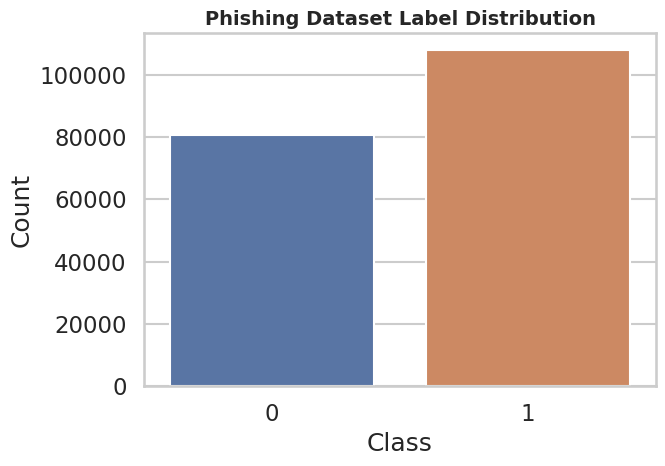

In [28]:
plt.figure(figsize=(7,5))

sns.countplot(
    x=y_train_phish,
    palette=modern_colors
)

plt.title("Phishing Dataset Label Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Class")
plt.ylabel("Count")

plt.tight_layout()

plt.show()

plt.savefig(
    os.path.join(PROJECT_ROOT, "figures", "phishing_distribution.png"),
    bbox_inches="tight",
    dpi=300
)

plt.close()

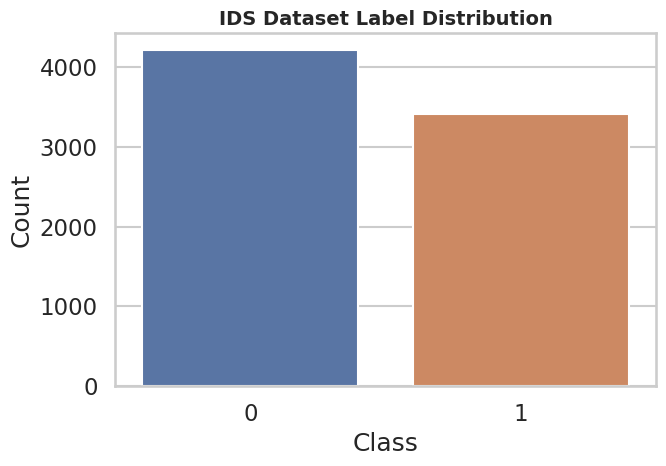

In [29]:
plt.figure(figsize=(7,5))

sns.countplot(
    x=y_train_ids,
    palette=modern_colors
)

plt.title("IDS Dataset Label Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Class")
plt.ylabel("Count")

plt.tight_layout()

plt.show()

plt.savefig(
    os.path.join(PROJECT_ROOT, "figures", "ids_distribution.png"),
    bbox_inches="tight",
    dpi=300
)

plt.close()

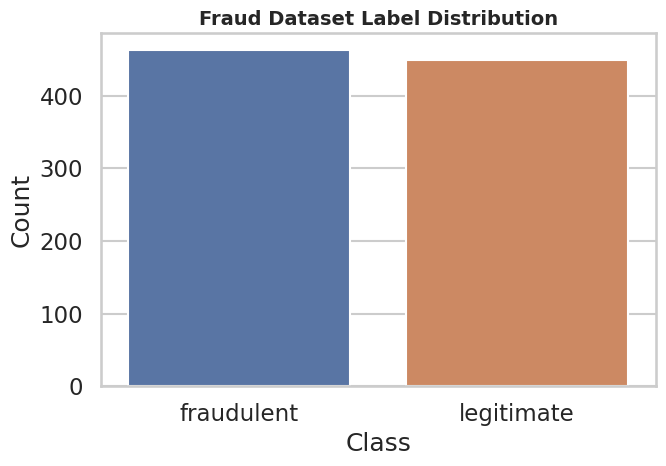

In [30]:
plt.figure(figsize=(7,5))

sns.countplot(
    x=y_train_fraud,
    palette=modern_colors
)

plt.title("Fraud Dataset Label Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Class")
plt.ylabel("Count")

plt.tight_layout()

plt.show()

plt.savefig(
    os.path.join(PROJECT_ROOT, "figures", "fraud_distribution.png"),
    bbox_inches="tight",
    dpi=300
)

plt.close()